# 스케일링 법칙: 모델 성능 예측 - 스케일링 법칙의 원리

- Tutorial ID: `adv-10-1`
- Tutorial: 스케일링 법칙: 모델 성능 예측
- Section ID: `adv-10-1-1`
- Section: 스케일링 법칙의 원리

## 이 노트북에서 배우는 것

1. **멱법칙(Power Law)** — 모델 파라미터 수가 커질수록 손실(loss)이 왜 예측 가능한 패턴으로 줄어드는지
2. **Chinchilla 스케일링 법칙** — 정해진 컴퓨팅 자원(예산)을 모델 크기와 데이터 양에 어떻게 나누는 것이 최적인지
3. 위 두 가지를 바탕으로 **실제 모델의 훈련 비용**(GPU 시간, 달러)을 어림잡아 계산하는 법

> 파이썬 기초 문법(반복문, 함수, `**` 거듭제곱 연산)만 알면 따라올 수 있도록 작성했습니다.
> 새로운 수식이 등장할 때마다 글로 먼저 풀어 설명한 뒤 코드로 넘어갑니다.
> 모든 코드는 numpy / matplotlib 만 사용합니다 (별도 설치 불필요).


In [1]:
# ============================================================
# 코드 읽는 법 — 스케일링 법칙의 원리
#
# 이 노트북은 "정답을 한 번 실행하고 끝내는" 용도가 아니라,
# 스케일링 법칙이라는 수학적 개념이 실제 숫자로 어떻게 나타나는지
# 한 줄씩 직접 계산해보며 확인하는 실습 노트입니다.
#
# 학습 목표:
#   1) 모델 파라미터 수(N)가 늘어날수록 손실(loss)이 "멱법칙"을 따라
#      예측 가능하게 줄어드는 과정을 직접 계산해본다.
#   2) 정해진 컴퓨팅 예산(C)을 모델 크기(N)와 데이터 양(D)에
#      어떤 비율로 나누는 것이 최적인지(Chinchilla 법칙) 확인한다.
#   3) 위 두 가지를 바탕으로, 실제 모델을 학습시키는 데 드는
#      GPU 시간과 비용을 어림잡아 계산해본다.
#
# 읽는 순서:
#   1) 각 절의 Markdown 설명을 먼저 읽고,
#      수식이 무엇을 의미하는지 이해합니다.
#   2) 코드 변수(N, D, C, alpha 등)가
#      수식의 어떤 기호에 대응하는지 확인합니다.
#   3) 작은 숫자 하나를 손으로 계산해 코드 결과와 비교합니다.
#   4) for문으로 여러 값을 비교하며 "경향(트렌드)"을 관찰합니다.
#   5) 그래프(matplotlib)로 그려서 눈으로도 패턴을 확인합니다.
#
# 주의:
#   - 정확한 숫자보다 "커질수록 어떻게 변하는가"라는 경향이 핵심입니다.
#   - numpy / matplotlib 만으로 동작합니다 (추가 설치 불필요).
# ============================================================


In [2]:
import numpy as np                   # 숫자 계산(거듭제곱, 배열 연산 등)
import matplotlib.pyplot as plt       # 그래프 그리기
import matplotlib.font_manager as fm  # 폰트 관리

# matplotlib 기본 폰트는 한글을 지원하지 않아 글자가 네모(□)로 깨질 수 있습니다.
# 아래 코드는 시스템에 설치된 한글 폰트를 자동으로 찾아 설정합니다.
KOREAN_KEYWORDS = [
    'Nanum', 'Malgun', 'AppleGothic',
    'Noto Sans CJK', 'Noto Sans KR',
    'UnDotum', 'Gulim', 'Dotum', 'Batang',
]
available = [f.name for f in fm.fontManager.ttflist]
korean_fonts = [n for n in available
                if any(kw in n for kw in KOREAN_KEYWORDS)]

if korean_fonts:
    plt.rcParams['font.family'] = korean_fonts[0]
    print(f"한글 폰트 '{korean_fonts[0]}'를 그래프에 사용합니다.")
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 안의 한글이 깨질 수 있습니다.")
    print("Google Colab 사용자라면 아래 명령어로 설치 후 런타임을 재시작하세요:")
    print("  !sudo apt-get install -y fonts-nanum && sudo fc-cache -fv")
    print("  !rm -rf ~/.cache/matplotlib")

# 한글 폰트 사용 시 마이너스(-) 부호가 깨지는 것을 방지합니다.
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("스케일링 법칙 (Scaling Laws)")
print("=" * 60)


한글 폰트 'Noto Sans CJK JP'를 그래프에 사용합니다.
스케일링 법칙 (Scaling Laws)


## 1. 멱법칙(Power Law)이란?

본격적인 수식에 앞서, 가장 단순한 예로 감을 잡아봅시다.

**멱법칙**이란 한 값이 다른 값의 거듭제곱(power)에 비례해서 변하는 관계입니다.

$$y = x^{p}$$

- 지수 $p$가 음수(예: $p = -0.5$)이면, $x$가 커질수록 $y$는 점점 작아집니다.
- 다만 처음에는 빠르게 줄다가, 갈수록 줄어드는 속도가 느려지는 **체감 효과**가 나타납니다.

아래 코드로 $y = x^{-0.5}$를 직접 계산해 이 패턴을 눈으로 확인해봅시다.


In [3]:
# ------------------------------------------------------------------
# 멱법칙(Power Law) 개념 확인 — 가장 단순한 예시
#
#   y = x^(-0.5)
#
# 지수(exponent)가 음수이면, x가 커질수록 y는 점점 작아집니다.
# "처음엔 빠르게 줄다가 갈수록 줄어드는 속도가 느려지는" 특징이 있습니다.
# 스케일링 법칙도 바로 이 패턴을 이용합니다.
# ------------------------------------------------------------------

print("간단한 멱법칙 예시: y = x^(-0.5)")
print("-" * 48)
print(f"{'x':>5s}   {'y = x^(-0.5)':>14s}   {'이전 값 대비':>12s}")

prev_y = None
for x in [1, 4, 16, 64, 256, 1024]:
    y = x ** (-0.5)        # 파이썬에서 거듭제곱은 ** 연산자를 사용합니다
    if prev_y is not None:
        ratio_str = f"{y / prev_y:.4f}배"
    else:
        ratio_str = "(기준)"
    print(f"  {x:>5d}   {y:>14.6f}   {ratio_str}")
    prev_y = y

print()
print("관찰:")
print("  x가 4배씩 늘어날 때마다 y는 항상 정확히 절반(0.5배)으로 줄어듭니다.")
print("  이처럼 '몇 배 커지면 몇 배 작아진다'는 일정한 비율 관계가 유지되는 것이")
print("  멱법칙의 핵심입니다.")
print()
print("  스케일링 법칙은 이 성질을 이용해 '모델을 N배 키우면 손실이 얼마나")
print("  줄어드는가'를 미리 예측합니다.")


간단한 멱법칙 예시: y = x^(-0.5)
------------------------------------------------
    x     y = x^(-0.5)        이전 값 대비
      1         1.000000   (기준)
      4         0.500000   0.5000배
     16         0.250000   0.5000배
     64         0.125000   0.5000배
    256         0.062500   0.5000배
   1024         0.031250   0.5000배

관찰:
  x가 4배씩 늘어날 때마다 y는 항상 정확히 절반(0.5배)으로 줄어듭니다.
  이처럼 '몇 배 커지면 몇 배 작아진다'는 일정한 비율 관계가 유지되는 것이
  멱법칙의 핵심입니다.

  스케일링 법칙은 이 성질을 이용해 '모델을 N배 키우면 손실이 얼마나
  줄어드는가'를 미리 예측합니다.


## 2. 모델 크기와 손실의 관계: Kaplan et al. 스케일링 법칙

OpenAI 연구진(Kaplan et al., 2020)은 다양한 크기의 언어 모델을 훈련시켜본 결과,
모델 파라미터 수($N$)와 검증 손실($L$) 사이에 다음과 같은 멱법칙 관계를 발견했습니다.

$$L(N) = \frac{a}{N^{\alpha_N}} + L_{\text{irreducible}}$$

| 기호 | 의미 |
|---|---|
| $N$ | 모델의 파라미터(가중치) 개수 |
| $L(N)$ | 그 크기에서 기대할 수 있는 손실. 작을수록 다음 토큰을 더 잘 예측합니다. |
| $\alpha_N$ | 스케일링 지수 — 손실이 얼마나 빠르게 줄어드는지를 결정 (논문 기준 약 0.076). |
| $a$ | 비례 상수 ($= N_c^{\alpha_N}$) |
| $L_{\text{irreducible}}$ | **줄일 수 없는 손실** — 자연어 자체의 불확실성에서 오는 하한선. |

핵심 직관: 모델을 키우면 앞 항 $a / N^{\alpha_N}$이 작아지지만, 아무리 키워도 $L_{\text{irreducible}}$ 밑으로는 내려가지 않습니다.
마치 "시험 문제 자체가 모호하면 100점을 받을 수 없는 것"과 같습니다.


In [4]:
# ------------------------------------------------------------------
# Kaplan et al. (2020) 스케일링 법칙
#
# 수식:  L(N) = a / N^(alpha_N)  +  L_irreducible
#
#   N               : 모델의 파라미터(가중치) 개수
#   alpha_N = 0.076 : 스케일링 지수. 손실이 얼마나 "빠르게" 줄어드는지를 결정합니다.
#                     (논문에서 다양한 크기의 모델을 실험해 측정한 값)
#   a               : 비례 상수. a = N_c^(alpha_N) 형태로 정의됩니다.
#   L_irreducible   : 줄일 수 없는 손실의 하한선.
#                     자연어 자체의 불확실성(다음 단어를 100% 확신할 수 없는 정도)에서 옵니다.
#                     모델을 아무리 키워도 이 값 아래로는 내려가지 않습니다.
# ------------------------------------------------------------------

print("1. 멱법칙: L(N) = a / N^(alpha_N) + L_irreducible")
print("-" * 48)

# Kaplan et al. (2020) 논문에서 사용한 근사 파라미터
alpha_N       = 0.076   # 모델 크기에 대한 스케일링 지수
L_irreducible = 1.69    # 줄일 수 없는 손실 (단위: nats. nats는 자연로그 기반의 정보량 단위)
N_c           = 8.8e13  # 비례 상수를 결정하는 기준 파라미터 수 (논문 제공값)
a_N           = N_c ** alpha_N   # 비례 상수 a 계산

print(f"  alpha_N       = {alpha_N}")
print(f"  L_irreducible = {L_irreducible}  (자연어 자체의 불확실성 하한)")
print(f"  N_c           = {N_c:.2e}  (비례 상수 기준값)")
print(f"  a_N = N_c ^ alpha_N = {N_c:.2e}^{alpha_N} = {a_N:.4f}")


def loss_vs_params(N):
    """
    모델 파라미터 수 N에서 스케일링 법칙으로 예측한 손실(loss)을 반환합니다.

    Parameters
    ----------
    N : float 또는 numpy 배열
        모델의 파라미터 개수 (예: 1e9 = 10억 개)

    Returns
    -------
    float 또는 numpy 배열
        예측 손실. 값이 작을수록 다음 토큰 예측을 더 잘 한다는 뜻입니다.
    """
    return (a_N / N ** alpha_N) + L_irreducible


1. 멱법칙: L(N) = a / N^(alpha_N) + L_irreducible
------------------------------------------------
  alpha_N       = 0.076
  L_irreducible = 1.69  (자연어 자체의 불확실성 하한)
  N_c           = 8.80e+13  (비례 상수 기준값)
  a_N = N_c ^ alpha_N = 8.80e+13^0.076 = 11.4757


In [5]:
# ------------------------------------------------------------------
# 손으로 따라가는 계산 예시 — N = 10억(1e9) 파라미터
#
# 수식을 세 단계로 나눠서 한 단계씩 계산합니다.
# 각 단계의 결과를 직접 출력해서 함수 결과와 비교해봅니다.
# ------------------------------------------------------------------

N_ex = 1e9   # 10억 개 파라미터 (GPT-2 XL이 약 1.5억, GPT-3가 약 1750억이니 그 중간 정도)

step1 = N_ex ** alpha_N            # ① N을 alpha_N 제곱
step2 = a_N / step1                # ② 비례 상수 a_N을 ①로 나누기 (멱법칙 항)
step3 = step2 + L_irreducible      # ③ 줄일 수 없는 손실을 더하기 (최종 손실)
fn_result = loss_vs_params(N_ex)   # 함수로 한 번에 구한 값 (같아야 합니다)

print("[예시] N = 1,000,000,000 (10억 개 파라미터) 일 때:")
print()
print(f"  ① N ^ alpha_N        = {N_ex:.0e} ^ {alpha_N}")
print(f"                       = {step1:.6f}")
print()
print(f"  ② a_N / (N^alpha_N)  = {a_N:.4f} / {step1:.6f}")
print(f"                       = {step2:.6f}  <- 이 항이 모델을 키울수록 작아지는 부분")
print()
print(f"  ③ + L_irreducible    = {step2:.6f} + {L_irreducible}")
print(f"                       = {step3:.6f}  <- 최종 예측 손실")
print()
print(f"  loss_vs_params(1e9) = {fn_result:.6f}  <- 함수로 구한 값 (③과 동일해야 합니다)")

# 두 값이 같은지 자동으로 확인
assert abs(step3 - fn_result) < 1e-10, "계산 불일치!"
print()
print("  검증 통과: 단계별 계산과 함수 결과가 일치합니다.")


[예시] N = 1,000,000,000 (10억 개 파라미터) 일 때:

  ① N ^ alpha_N        = 1e+09 ^ 0.076
                       = 4.830588

  ② a_N / (N^alpha_N)  = 11.4757 / 4.830588
                       = 2.375640  <- 이 항이 모델을 키울수록 작아지는 부분

  ③ + L_irreducible    = 2.375640 + 1.69
                       = 4.065640  <- 최종 예측 손실

  loss_vs_params(1e9) = 4.065640  <- 함수로 구한 값 (③과 동일해야 합니다)

  검증 통과: 단계별 계산과 함수 결과가 일치합니다.


In [6]:
# ------------------------------------------------------------------
# 여러 모델 크기에서 손실을 한 번에 비교
#
# 막대(█) 길이는 "아직 줄일 수 있는 손실" = loss - L_irreducible 에 비례합니다.
# N이 클수록 막대가 짧아지지만, 완전히 사라지지는 않습니다.
# ------------------------------------------------------------------

print("모델 크기 vs 예측 손실 (L_irreducible = 1.69 기준)")
print(f"  {'파라미터 수':>13s}   {'예측 손실 L':>10s}   줄일 수 있는 손실 (막대)")

params_list = [1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
prev_loss = None

for n_params in params_list:
    loss = loss_vs_params(n_params)
    reducible = loss - L_irreducible   # 모델을 키워서 줄일 수 있는 부분
    bar = '█' * max(0, int(reducible * 6))
    label = f"{n_params:.0e}"

    if prev_loss is not None:
        drop_pct = (prev_loss - loss) / prev_loss * 100
        drop_str = f"  (이전 대비 -{drop_pct:.1f}%)"
    else:
        drop_str = "  (기준)"

    print(f"  {label:>13s}   L = {loss:.4f}   {bar}{drop_str}")
    prev_loss = loss

print()
print("  관찰 1: N이 10배씩 커질 때마다 손실이 줄어드는 양은 점점 작아집니다.")
print("  관찰 2: L_irreducible(= 1.69) 아래로는 아무리 키워도 내려가지 않습니다.")
print("          이는 자연어 자체가 가진 불확실성의 하한이기 때문입니다.")


모델 크기 vs 예측 손실 (L_irreducible = 1.69 기준)
         파라미터 수      예측 손실 L   줄일 수 있는 손실 (막대)
          1e+06   L = 5.7059   ████████████████████████  (기준)
          1e+07   L = 5.0612   ████████████████████  (이전 대비 -11.3%)
          1e+08   L = 4.5200   ████████████████  (이전 대비 -10.7%)
          1e+09   L = 4.0656   ██████████████  (이전 대비 -10.1%)
          1e+10   L = 3.6843   ███████████  (이전 대비 -9.4%)
          1e+11   L = 3.3641   ██████████  (이전 대비 -8.7%)
          1e+12   L = 3.0953   ████████  (이전 대비 -8.0%)

  관찰 1: N이 10배씩 커질 때마다 손실이 줄어드는 양은 점점 작아집니다.
  관찰 2: L_irreducible(= 1.69) 아래로는 아무리 키워도 내려가지 않습니다.
          이는 자연어 자체가 가진 불확실성의 하한이기 때문입니다.


### 그래프로 확인하기 — 왜 로그-로그 스케일인가?

스케일링 논문들은 항상 **양쪽 축 모두를 로그 스케일**로 그립니다. 이유는 두 가지입니다.

1. **범위 문제**: $N$이 100만에서 1조까지 변하면, 선형 스케일에서는 작은 값들이 한쪽에 뭉쳐 보입니다.
2. **패턴 확인**: 순수한 멱법칙 관계는 로그-로그 그래프에서 **직선**으로 나타납니다. 직선의 기울기가 $-\alpha_N$입니다.

아래 그래프에서 선형 스케일과 로그-로그 스케일을 나란히 비교해봅니다.


왼쪽(선형): N이 작을 때만 변화가 뚜렷하고, 오른쪽 절반은 거의 평평해 보입니다.
오른쪽(로그-로그): 점선(순수 멱법칙)은 직선이지만, L_irreducible 때문에
  N이 아주 클 때는 실선이 평평하게 꺾입니다.

로그-로그 그래프에서 '기울기' = -alpha_N = -0.076 입니다.
  즉, x축이 10배(한 칸) 커질 때 y축은 10^0.076 ≈ 1.19배 작아집니다.


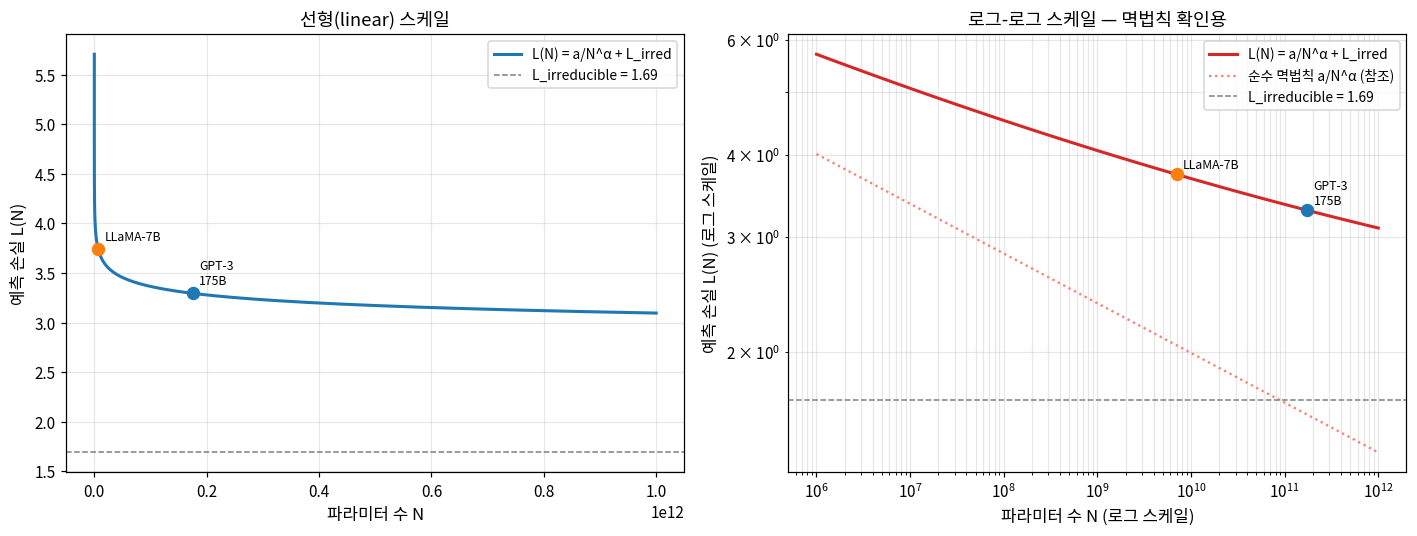

In [7]:
# ------------------------------------------------------------------
# 스케일링 법칙을 그래프로 확인
#
# 왜 로그-로그 스케일로 그릴까?
#   - 선형 스케일: N이 1백만~1조까지 변하면, 작은 N 값들이 왼쪽에 몰려 잘 보이지 않습니다.
#   - 로그-로그 스케일: 순수한 멱법칙은 "직선"으로 나타납니다.
#     직선이 조금 휘어지는 부분이 L_irreducible의 영향입니다.
# ------------------------------------------------------------------

# 100만(1e6)부터 1조(1e12)까지, 로그 간격으로 100개 점을 생성합니다.
N_range = np.logspace(6, 12, 100)
L_range = loss_vs_params(N_range)

# L_irreducible만 있는 순수 멱법칙 (비교용 참조선)
L_pure_power = a_N / N_range ** alpha_N    # L_irreducible 제외한 멱법칙 항만

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ----- 왼쪽: 선형 스케일 -----
ax = axes[0]
ax.plot(N_range, L_range, color='tab:blue', lw=2, label='L(N) = a/N^α + L_irred')
ax.axhline(L_irreducible, color='gray', ls='--', lw=1, label=f'L_irreducible = {L_irreducible}')
ax.set_xlabel('파라미터 수 N', fontsize=11)
ax.set_ylabel('예측 손실 L(N)', fontsize=11)
ax.set_title('선형(linear) 스케일', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 실제 모델 위치를 점으로 표시
real_pts = [('GPT-3\n175B', 175e9), ('LLaMA-7B', 7e9)]
for name, n in real_pts:
    ax.scatter([n], [loss_vs_params(n)], s=60, zorder=5)
    ax.annotate(name, (n, loss_vs_params(n)), textcoords='offset points',
                xytext=(4, 6), fontsize=8)

# ----- 오른쪽: 로그-로그 스케일 -----
ax = axes[1]
ax.plot(N_range, L_range, color='tab:red', lw=2, label='L(N) = a/N^α + L_irred')
ax.plot(N_range, L_pure_power, color='salmon', lw=1.5, ls=':', label='순수 멱법칙 a/N^α (참조)')
ax.axhline(L_irreducible, color='gray', ls='--', lw=1, label=f'L_irreducible = {L_irreducible}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('파라미터 수 N (로그 스케일)', fontsize=11)
ax.set_ylabel('예측 손실 L(N) (로그 스케일)', fontsize=11)
ax.set_title('로그-로그 스케일 — 멱법칙 확인용', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

for name, n in real_pts:
    ax.scatter([n], [loss_vs_params(n)], s=60, zorder=5)
    ax.annotate(name, (n, loss_vs_params(n)), textcoords='offset points',
                xytext=(4, 4), fontsize=8)

plt.tight_layout()
plt.show()

print("왼쪽(선형): N이 작을 때만 변화가 뚜렷하고, 오른쪽 절반은 거의 평평해 보입니다.")
print("오른쪽(로그-로그): 점선(순수 멱법칙)은 직선이지만, L_irreducible 때문에")
print("  N이 아주 클 때는 실선이 평평하게 꺾입니다.")
print()
print("로그-로그 그래프에서 '기울기' = -alpha_N = -0.076 입니다.")
print("  즉, x축이 10배(한 칸) 커질 때 y축은 10^0.076 ≈ 1.19배 작아집니다.")


## 3. 정해진 예산을 어떻게 나눌까? Chinchilla 최적 비율

"모델을 키우면 성능이 좋아진다"는 것을 알았습니다. 그런데 훈련에는 **컴퓨팅 예산**(GPU, 시간, 비용)이 듭니다.
같은 예산이라면 어디에 더 쓰는 게 좋을까요?

- **모델을 더 크게** ($N$ 증가) vs **데이터를 더 많이** ($D$ 증가)

공부 비유로 생각하면: 정해진 시간을 "새 단원을 배우는 것"($N$)과 "배운 내용을 복습·문제 풀기"($D$)에
어떻게 나눌까요? 적절한 균형이 필요합니다.

DeepMind(Hoffmann et al., 2022)는 이 균형점을 실험으로 찾아 **Chinchilla** 모델을 만들었습니다.

### 컴퓨팅 예산 공식

$$C \approx 6 \cdot N \cdot D$$

- $C$: 총 FLOPs (부동소수점 연산 횟수)
- 계수 **6**의 유래: 순전파(forward) ≈ 2번, 역전파(backward) ≈ 4번 → 합 6번

### Chinchilla 최적 비율

$$D_{\text{opt}} \approx 20 \times N_{\text{opt}}$$

**"파라미터 1개당 토큰 약 20개"** 가 훈련 효율을 최대화하는 비율입니다.


In [8]:
# ------------------------------------------------------------------
# Chinchilla 최적 비율 (Hoffmann et al., DeepMind 2022)
#
# 핵심 질문: 정해진 컴퓨팅 예산 C로 훈련할 때,
#   "모델 크기 N" 과 "데이터 양 D" 를 어떤 비율로 나눠야 손실이 최소일까?
#
# 컴퓨팅 예산 공식:
#   C ≈ 6 * N * D   (FLOPs 단위)
#
#   계수 6의 유래:
#     토큰 1개를 학습할 때 파라미터 1개당 필요한 연산:
#       순전파(forward)  : 2번 (곱셈 1 + 덧셈 1)
#       역전파(backward) : 4번 (순전파의 약 2배)
#       합계 = 6번 → C = 6 * N * D
#
# Chinchilla 논문이 찾은 최적 비율:
#   D_opt ≈ 20 * N_opt
#   즉, "파라미터 1개당 토큰 약 20개"가 훈련 관점에서 최적입니다.
#
# N_opt 유도 과정:
#   1) C = 6 * N * D
#   2) D = 20 * N 대입
#   => C = 6 * N * 20N = 120 * N^2
#   => N = sqrt(C / 120)
# ------------------------------------------------------------------

print("2. Chinchilla 최적 비율")
print("-" * 48)


def chinchilla_optimal(compute_budget):
    """
    주어진 컴퓨팅 예산(C)에 대해, Chinchilla 법칙이 권장하는
    최적의 모델 크기(N)와 데이터 양(D)을 반환합니다.

    Parameters
    ----------
    compute_budget : float
        총 컴퓨팅 예산 (FLOPs 단위)

    Returns
    -------
    (N_opt, D_opt) : tuple of float
        최적 파라미터 수, 최적 토큰 수
    """
    N_opt = np.sqrt(compute_budget / 120)  # C = 120*N^2 => N = sqrt(C/120)
    D_opt = 20 * N_opt                     # D = 20 * N
    return N_opt, D_opt


print("Chinchilla_optimal 함수 유도 요약:")
print("  C = 6·N·D   (컴퓨팅 예산 공식)")
print("  D = 20·N    (Chinchilla 최적 비율)")
print("  → C = 120·N²  → N = sqrt(C / 120)")


2. Chinchilla 최적 비율
------------------------------------------------
Chinchilla_optimal 함수 유도 요약:
  C = 6·N·D   (컴퓨팅 예산 공식)
  D = 20·N    (Chinchilla 최적 비율)
  → C = 120·N²  → N = sqrt(C / 120)


In [9]:
# ------------------------------------------------------------------
# 손으로 따라가는 계산 예시 — C = 1e21 FLOPs
# ------------------------------------------------------------------

C_ex = 1e21

# 단계별 계산
step_N = np.sqrt(C_ex / 120)    # N_opt = sqrt(C / 120)
step_D = 20 * step_N             # D_opt = 20 * N_opt
verify  = 6 * step_N * step_D   # 검산: 6·N·D 가 원래 C와 같아야 함

print(f"[예시] 컴퓨팅 예산 C = {C_ex:.1e} FLOPs 일 때:")
print()
print(f"  ① N_opt = sqrt(C / 120)")
print(f"          = sqrt({C_ex:.1e} / 120)")
print(f"          = {step_N:.4e}  개 파라미터")
print()
print(f"  ② D_opt = 20 × N_opt")
print(f"          = 20 × {step_N:.4e}")
print(f"          = {step_D:.4e}  개 토큰")
print()
print(f"  검산: 6 × N_opt × D_opt = {verify:.4e}")
print(f"  원래 예산 C             = {C_ex:.4e}")
print(f"  (두 값이 같으면 계산 성공)")

N_fn, D_fn = chinchilla_optimal(C_ex)
assert abs(step_N - N_fn) < 1, "N_opt 불일치!"
assert abs(step_D - D_fn) < 1, "D_opt 불일치!"
print()
print("  검증 통과: 단계별 계산과 함수 결과가 일치합니다.")


[예시] 컴퓨팅 예산 C = 1.0e+21 FLOPs 일 때:

  ① N_opt = sqrt(C / 120)
          = sqrt(1.0e+21 / 120)
          = 2.8868e+09  개 파라미터

  ② D_opt = 20 × N_opt
          = 20 × 2.8868e+09
          = 5.7735e+10  개 토큰

  검산: 6 × N_opt × D_opt = 1.0000e+21
  원래 예산 C             = 1.0000e+21
  (두 값이 같으면 계산 성공)

  검증 통과: 단계별 계산과 함수 결과가 일치합니다.


In [10]:
# ------------------------------------------------------------------
# 예산 규모별 최적 N과 D — 한눈에 비교
# ------------------------------------------------------------------

print("컴퓨팅 예산별 Chinchilla 최적 모델 크기와 데이터 양:")
print()
print(f"  {'계산량 C (FLOPs)':>18s}   {'최적 N (파라미터)':>18s}   "
      f"{'최적 D (토큰)':>15s}   {'D/N 비율':>9s}")

budgets = [1e18, 1e19, 1e20, 1e21, 1e22, 1e23]
for C in budgets:
    N, D = chinchilla_optimal(C)
    print(f"  {C:>18.1e}   {N:>18.3e}   {D:>15.3e}   {D/N:>7.0f}x")

print()
print("  관찰: D/N 비율이 항상 20입니다.")
print("        이는 함수에 D = 20*N 관계를 직접 사용했기 때문이며,")
print("        Chinchilla 논문에서 실험적으로 도출한 근사 비율입니다.")
print()
print("  관찰: C가 100배(10^2) 커질 때 N_opt는 약 10배(10^1) 커집니다.")
print("        N ∝ sqrt(C) 관계 때문입니다. 즉, 컴퓨팅을 100배 늘려야")
print("        모델 크기를 10배 키울 수 있습니다.")


컴퓨팅 예산별 Chinchilla 최적 모델 크기와 데이터 양:

       계산량 C (FLOPs)          최적 N (파라미터)         최적 D (토큰)      D/N 비율
             1.0e+18            9.129e+07         1.826e+09        20x
             1.0e+19            2.887e+08         5.774e+09        20x
             1.0e+20            9.129e+08         1.826e+10        20x
             1.0e+21            2.887e+09         5.774e+10        20x
             1.0e+22            9.129e+09         1.826e+11        20x
             1.0e+23            2.887e+10         5.774e+11        20x

  관찰: D/N 비율이 항상 20입니다.
        이는 함수에 D = 20*N 관계를 직접 사용했기 때문이며,
        Chinchilla 논문에서 실험적으로 도출한 근사 비율입니다.

  관찰: C가 100배(10^2) 커질 때 N_opt는 약 10배(10^1) 커집니다.
        N ∝ sqrt(C) 관계 때문입니다. 즉, 컴퓨팅을 100배 늘려야
        모델 크기를 10배 키울 수 있습니다.


### 실제 모델은 이 비율을 지켰을까?

아래 표와 그래프에서 실제 공개 모델들의 D/N 비율을 Chinchilla 권장치(20×)와 비교합니다.

- **과소훈련(undertrained)**: 모델은 큰데 데이터가 부족 → 같은 크기로 더 많이 학습시키면 성능을 높일 수 있었다는 뜻
- **Chinchilla 최적**: 주어진 예산 안에서 *훈련 손실*을 최소화하는 균형점
- **과훈련(overtrained)**: Chinchilla 비율보다 더 많은 데이터 사용 → 훈련 효율보다 **추론 품질**을 우선시한 선택.
  모델은 한 번 학습하지만 추론은 수백만 번 일어나므로, 최근에는 의도적으로 이 방향을 선택하는 경우가 많습니다.


실제 모델 D/N 비율 비교 (Chinchilla 권장치: 약 20):

                모델            N            D       D/N   해석
        GPT-3 175B      1.8e+11      3.0e+11       1.7x   과소훈련 — 같은 N 대비 데이터 부족
    Chinchilla 70B      7.0e+10      1.4e+12      20.0x   Chinchilla 최적 근접
       LLaMA-2 70B      7.0e+10      2.0e+12      28.6x   과훈련 — 추론 효율 우선 선택
       LLaMA-3 70B      7.0e+10      1.5e+13     214.3x   과훈련 — 추론 효율 우선 선택

  그래프 읽는 법:
  - 점선(최적선) 위쪽 : D/N > 20  → 과훈련 (데이터를 비율보다 더 많이 사용)
  - 점선(최적선) 아래쪽: D/N < 20  → 과소훈련 (데이터가 비율보다 부족)

  GPT-3는 점선보다 아래(과소훈련), LLaMA-3는 점선보다 훨씬 위(과훈련)에 있습니다.
  LLaMA-3처럼 의도적으로 과훈련하면, 모델이 작아도 추론 품질이 높아지는
  실용적 이점이 있습니다 (모델은 한 번 학습, 추론은 수백만 번 발생하기 때문).


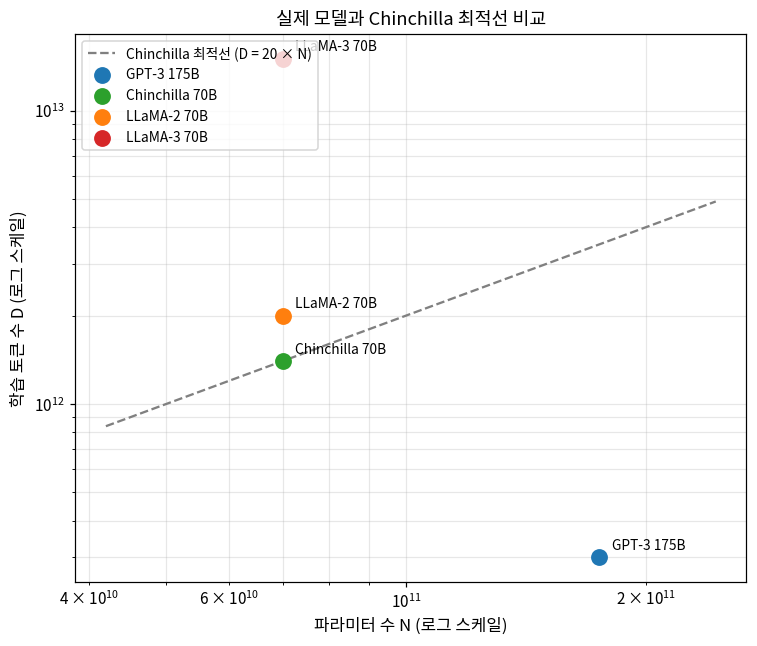

In [11]:
# ------------------------------------------------------------------
# 실제 공개 모델들의 (N, D) vs Chinchilla 최적선 비교
#
# D/N 비율이 20에 가까울수록 "훈련 컴퓨팅 효율" 관점에서 최적에 가깝습니다.
# 단, 실무에서는 추론(inference) 비용까지 고려하므로 의도적으로
# 이 비율을 초과(더 많은 데이터로 학습)하는 경향도 있습니다.
# ------------------------------------------------------------------

# (모델 이름, 파라미터 수 N, 학습 토큰 수 D)
real_models = [
    ("GPT-3 175B",     175e9,  300e9),
    ("Chinchilla 70B",  70e9,  1.4e12),
    ("LLaMA-2 70B",     70e9,  2.0e12),
    ("LLaMA-3 70B",     70e9, 15.0e12),
]

print("실제 모델 D/N 비율 비교 (Chinchilla 권장치: 약 20):")
print()
print(f"  {'모델':>16s}   {'N':>10s}   {'D':>10s}   {'D/N':>7s}   해석")

for name, N, D in real_models:
    ratio = D / N
    if ratio < 15:
        verdict = "과소훈련 — 같은 N 대비 데이터 부족"
    elif ratio <= 25:
        verdict = "Chinchilla 최적 근접"
    else:
        verdict = "과훈련 — 추론 효율 우선 선택"
    print(f"  {name:>16s}   {N:>10.1e}   {D:>10.1e}   {ratio:>7.1f}x   {verdict}")

print()

# ---------- 산점도 ----------
fig, ax = plt.subplots(figsize=(7, 6))

# Chinchilla 최적 비율선 (D = 20*N)
N_all = [N for _, N, D in real_models]
N_line = np.logspace(
    np.log10(min(N_all) * 0.6),
    np.log10(max(N_all) * 1.4),
    60
)
ax.plot(N_line, 20 * N_line, '--', color='gray', lw=1.5,
        label='Chinchilla 최적선 (D = 20 × N)')

# 실제 모델 점
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']
for (name, N, D), c in zip(real_models, colors):
    ax.scatter(N, D, s=100, color=c, zorder=4, label=name)
    ax.annotate(name, (N, D), textcoords='offset points',
                xytext=(8, 5), fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('파라미터 수 N (로그 스케일)', fontsize=11)
ax.set_ylabel('학습 토큰 수 D (로그 스케일)', fontsize=11)
ax.set_title('실제 모델과 Chinchilla 최적선 비교', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("  그래프 읽는 법:")
print("  - 점선(최적선) 위쪽 : D/N > 20  → 과훈련 (데이터를 비율보다 더 많이 사용)")
print("  - 점선(최적선) 아래쪽: D/N < 20  → 과소훈련 (데이터가 비율보다 부족)")
print()
print("  GPT-3는 점선보다 아래(과소훈련), LLaMA-3는 점선보다 훨씬 위(과훈련)에 있습니다.")
print("  LLaMA-3처럼 의도적으로 과훈련하면, 모델이 작아도 추론 품질이 높아지는")
print("  실용적 이점이 있습니다 (모델은 한 번 학습, 추론은 수백만 번 발생하기 때문).")


## 4. 실제 훈련 비용 추정하기

컴퓨팅 자원을 **실제 GPU로 처리하면 얼마나 걸리고, 비용은 얼마인지** 어림잡아 계산합니다.

$$\text{GPU 시간} = \frac{6 \cdot N \cdot D}{\text{TFLOPS} \times 3600 \times 10^{12}}$$
$$\text{비용(\$)} = \text{GPU 시간} \times \text{시간당 단가}$$

> **TFLOPS**: Tera FLOPs per Second = 초당 1조 번 연산. GPU 성능 단위입니다.

> **주의**: GPU는 이론 성능의 30~50% 정도만 실제로 활용됩니다(이를 **MFU**, Model FLOPs Utilization이라 합니다).
> 아래 추정치는 이를 반영해 150 TFLOPS를 사용하지만, 실제 비용은 병렬화 오버헤드 등으로 인해 보통 2~3배 이상 높습니다.


In [12]:
# ------------------------------------------------------------------
# 실제 훈련 비용 추정
#
# 세 단계로 계산합니다:
#   ① 총 연산량(FLOPs)   : C = 6 * N * D
#   ② GPU 처리 시간(초)  : total_seconds = C / (gpu_tflops * 1e12)
#   ③ 비용 환산(달러)    : cost = (total_seconds / 3600) * gpu_price_hr
#
# TFLOPS란?
#   T = Tera = 1조(10^12)
#   FLOPS = FLoating-point OPeration per Second (1초당 부동소수점 연산 횟수)
#   150 TFLOPS = 1초에 150조 번 연산
#
# 주의: 이론 성능(peak TFLOPS)과 실제 활용률(MFU)의 차이
#   GPU는 이론적 최대 성능을 항상 100% 발휘하지 않습니다.
#   실제 훈련에서는 GPU 간 통신, 메모리 병목 등으로 보통 30~50% 수준만 활용됩니다.
#   이 비율을 MFU(Model FLOPs Utilization)라고 부릅니다.
#   아래에서는 이미 MFU를 어느 정도 반영해 150 TFLOPS를 사용합니다.
# ------------------------------------------------------------------

print("3. 실제 훈련 비용 추정")
print("-" * 48)


def training_cost(N, D, gpu_tflops=150.0, gpu_price_hr=3.0):
    """
    모델 크기(N)와 데이터 양(D)으로부터 훈련 비용을 추정합니다.
    (NVIDIA A100 GPU 1대 기준 근사치)

    Parameters
    ----------
    N : float
        모델 파라미터 수
    D : float
        학습 토큰 수
    gpu_tflops : float, default 150.0
        GPU 1대가 1초에 처리하는 연산량 (TFLOPS).
        A100의 BF16 이론값(~312 TFLOPS)에 MFU를 반영한 근사값입니다.
    gpu_price_hr : float, default 3.0
        GPU 1대를 1시간 빌리는 비용 (달러)

    Returns
    -------
    (gpu_hours, cost) : tuple of float
        예상 GPU 시간, 예상 비용(달러)
    """
    C_flops = 6 * N * D                          # ① 총 연산량
    seconds = C_flops / (gpu_tflops * 1e12)       # ② 초 단위 처리 시간 (GPU 1대 기준)
    gpu_hours = seconds / 3600                    # 초 → 시간
    cost = gpu_hours * gpu_price_hr               # ③ 비용 환산
    return gpu_hours, cost


# 손으로 따라가는 예시: LLaMA-7B
N_ex, D_ex = 7e9, 1e12
C_ex    = 6 * N_ex * D_ex
sec_ex  = C_ex / (150 * 1e12)
hrs_ex, cost_ex = training_cost(N_ex, D_ex)

print(f"[예시] LLaMA-7B 학습 비용 추정 (N={N_ex:.0e}, D={D_ex:.0e})")
print()
print(f"  ① 총 연산량  C = 6 × {N_ex:.0e} × {D_ex:.0e}")
print(f"                  = {C_ex:.3e} FLOPs")
print()
print(f"  ② GPU 처리   = {C_ex:.3e} / (150 × 10^12)")
print(f"    시간(초)    = {sec_ex:,.0f}초")
print(f"    시간(h)     = {sec_ex/3600:,.0f}시간  ← 이것이 'GPU 시간(GPU-hours)'")
print()
print(f"  ③ 비용      = {sec_ex/3600:,.0f}h × $3/h ≈ ${cost_ex:,.0f}")
print()
print("  참고: GPU를 1000대 병렬로 쓰면 '달력 시간'은 1/1000이 됩니다.")
print("        'GPU 시간'은 GPU 1대 기준 총 작업량이라고 이해하세요.")


3. 실제 훈련 비용 추정
------------------------------------------------
[예시] LLaMA-7B 학습 비용 추정 (N=7e+09, D=1e+12)

  ① 총 연산량  C = 6 × 7e+09 × 1e+12
                  = 4.200e+22 FLOPs

  ② GPU 처리   = 4.200e+22 / (150 × 10^12)
    시간(초)    = 280,000,000초
    시간(h)     = 77,778시간  ← 이것이 'GPU 시간(GPU-hours)'

  ③ 비용      = 77,778h × $3/h ≈ $233,333

  참고: GPU를 1000대 병렬로 쓰면 '달력 시간'은 1/1000이 됩니다.
        'GPU 시간'은 GPU 1대 기준 총 작업량이라고 이해하세요.


모델별 훈련 비용 추정 (A100 기준, gpu_tflops=150, $3/h)

                모델            N           D          GPU 시간         비용(USD)
       GPT-2 Small      1.2e+08     3.0e+11          413 h   $     1,240
       GPT-2 Large      7.7e+08     3.0e+11        2,580 h   $     7,740
          LLaMA-7B      7.0e+09     1.0e+12       77,778 h   $   233,333
         LLaMA-70B      7.0e+10     2.0e+12    1,555,556 h   $ 4,666,667
        GPT-4 (추정)      1.8e+12     1.3e+13   260,000,000 h   $780,000,000

  * GPT-4 수치는 공식 미공개 — 외부 추정값입니다.
  * 실제 비용은 GPU 활용률(MFU), 병렬화 오버헤드 등으로 인해
    위 추정치보다 보통 2~3배 이상 높습니다.


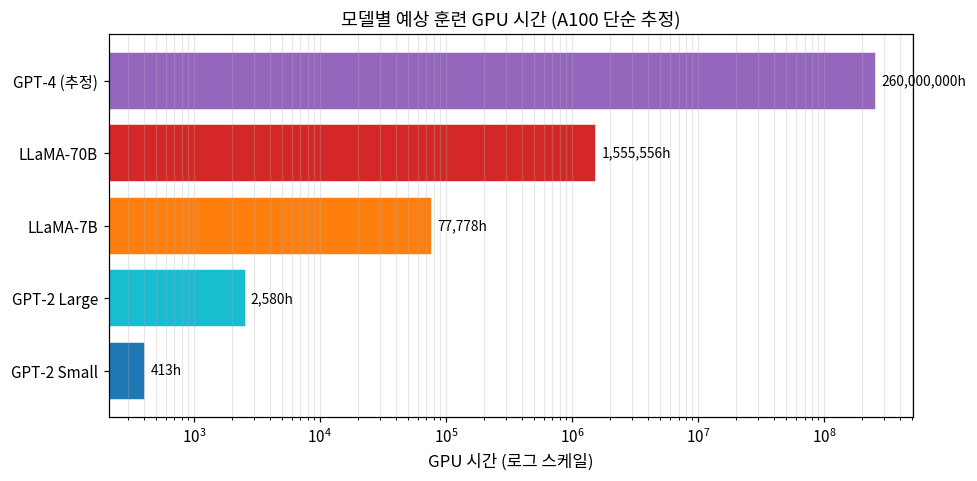

In [13]:
# ------------------------------------------------------------------
# 실제 모델별 훈련 비용 비교 (A100 기준 단순 추정)
# ------------------------------------------------------------------

models = [
    # (이름,           파라미터 수 N,  학습 토큰 수 D)
    ("GPT-2 Small",   124e6,   300e9),
    ("GPT-2 Large",   774e6,   300e9),
    ("LLaMA-7B",      7e9,     1e12),
    ("LLaMA-70B",    70e9,     2e12),
    ("GPT-4 (추정)", 1.8e12,  13e12),
]

print("모델별 훈련 비용 추정 (A100 기준, gpu_tflops=150, $3/h)")
print()
print(f"  {'모델':>16s}   {'N':>10s}   {'D':>9s}   "
      f"{'GPU 시간':>13s}   {'비용(USD)':>13s}")

hours_list = []
names_list = []
for name, N, D in models:
    hrs, cost = training_cost(N, D)
    hours_list.append(hrs)
    names_list.append(name)
    print(f"  {name:>16s}   {N:>10.1e}   {D:>9.1e}   "
          f"{hrs:>10,.0f} h   ${cost:>10,.0f}")

print()
print("  * GPT-4 수치는 공식 미공개 — 외부 추정값입니다.")
print("  * 실제 비용은 GPU 활용률(MFU), 병렬화 오버헤드 등으로 인해")
print("    위 추정치보다 보통 2~3배 이상 높습니다.")

# ----- 가로 막대 그래프 -----
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_bar = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red', 'tab:purple']
bars = ax.barh(names_list, hours_list, color=colors_bar, edgecolor='white')

ax.set_xscale('log')
ax.set_xlabel('GPU 시간 (로그 스케일)', fontsize=11)
ax.set_title('모델별 예상 훈련 GPU 시간 (A100 단순 추정)', fontsize=12)
ax.grid(axis='x', alpha=0.3, which='both')

for bar, h in zip(bars, hours_list):
    ax.text(h * 1.1, bar.get_y() + bar.get_height() / 2,
            f'{h:,.0f}h', va='center', fontsize=9)

plt.tight_layout()
plt.show()


> **참고**: GPT-4의 파라미터 수와 학습 토큰 수는 OpenAI가 공식 공개하지 않았습니다.
> 위 표의 수치는 외부 추정값(분석/루머)이며 검증된 사실이 아닙니다.
> GPT-2와 LLaMA 시리즈는 각각 OpenAI와 Meta가 공식 공개한 수치입니다.


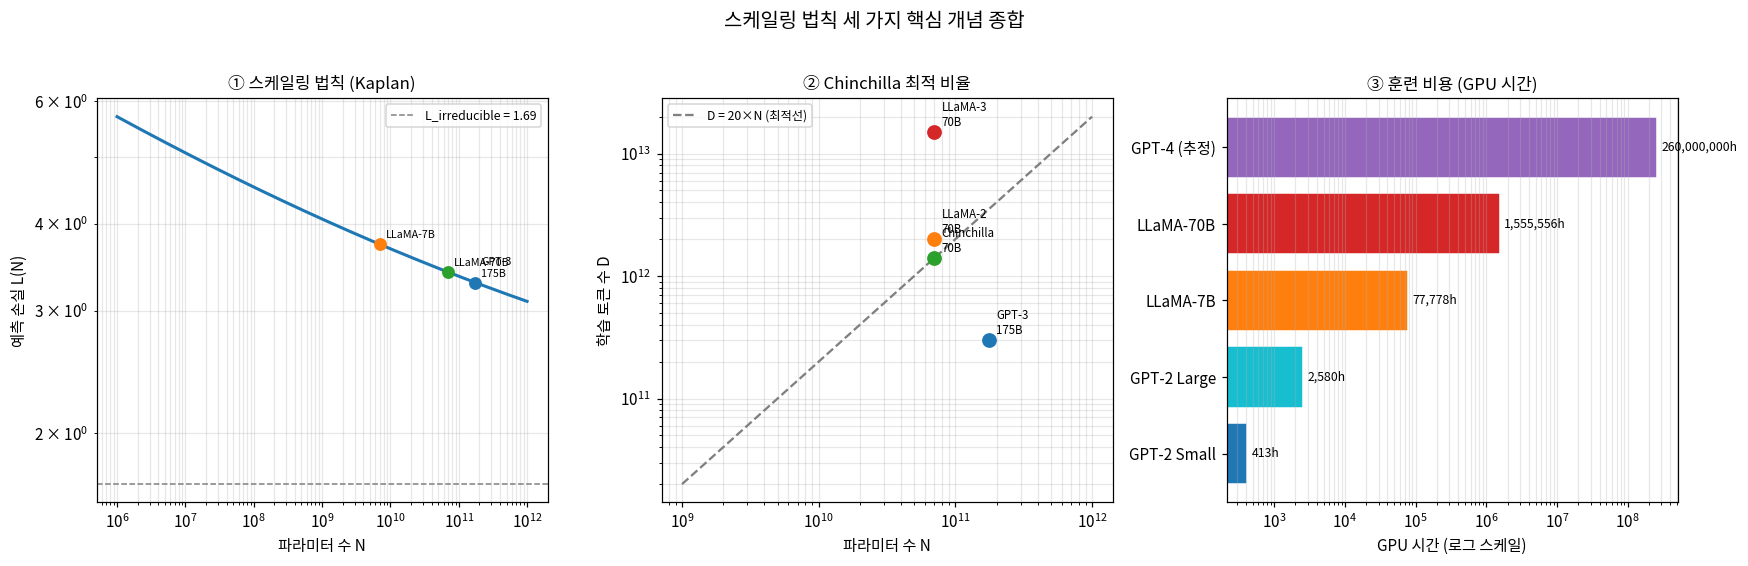

In [14]:
# ------------------------------------------------------------------
# 종합 시각화: 멱법칙 / Chinchilla 최적선 / 훈련 비용
#
# 세 가지 핵심 개념을 한 화면에 나란히 그려서 전체 맥락을 확인합니다.
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- ① 손실 vs 파라미터 수 (멱법칙) ----
ax = axes[0]
N_arr = np.logspace(6, 12, 200)
L_arr = loss_vs_params(N_arr)
ax.plot(N_arr, L_arr, color='tab:blue', lw=2)
ax.axhline(L_irreducible, color='gray', ls='--', lw=1,
           label=f'L_irreducible = {L_irreducible}')

real_pts = [("GPT-3\n175B", 175e9), ("LLaMA-7B", 7e9), ("LLaMA-70B", 70e9)]
for name, n in real_pts:
    ax.scatter(n, loss_vs_params(n), s=55, zorder=5)
    ax.annotate(name, (n, loss_vs_params(n)),
                textcoords='offset points', xytext=(4, 4), fontsize=7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('파라미터 수 N', fontsize=10)
ax.set_ylabel('예측 손실 L(N)', fontsize=10)
ax.set_title('① 스케일링 법칙 (Kaplan)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# ---- ② Chinchilla 최적선과 실제 모델 ----
ax = axes[1]
N_line = np.logspace(9, 12, 60)
ax.plot(N_line, 20 * N_line, '--', color='gray', lw=1.5, label='D = 20×N (최적선)')

real_models_full = [
    ("GPT-3\n175B",     175e9,  300e9,  'tab:blue'),
    ("Chinchilla\n70B",  70e9,  1.4e12, 'tab:green'),
    ("LLaMA-2\n70B",     70e9,  2.0e12, 'tab:orange'),
    ("LLaMA-3\n70B",     70e9, 15.0e12, 'tab:red'),
]
for name, N, D, c in real_models_full:
    ax.scatter(N, D, s=75, color=c, zorder=4)
    ax.annotate(name, (N, D), textcoords='offset points',
                xytext=(5, 4), fontsize=7.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('파라미터 수 N', fontsize=10)
ax.set_ylabel('학습 토큰 수 D', fontsize=10)
ax.set_title('② Chinchilla 최적 비율', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# ---- ③ 훈련 비용 막대 ----
ax = axes[2]
model_names = [m[0] for m in models]
gpu_hrs     = [training_cost(m[1], m[2])[0] for m in models]
colors_b    = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red', 'tab:purple']
ax.barh(model_names, gpu_hrs, color=colors_b, edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('GPU 시간 (로그 스케일)', fontsize=10)
ax.set_title('③ 훈련 비용 (GPU 시간)', fontsize=11)
ax.grid(axis='x', alpha=0.3, which='both')

for i, h in enumerate(gpu_hrs):
    ax.text(h * 1.15, i, f'{h:,.0f}h', va='center', fontsize=8)

plt.suptitle('스케일링 법칙 세 가지 핵심 개념 종합', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 정리하며

이번 노트북에서 다룬 세 가지 핵심 아이디어입니다.

| 개념 | 핵심 공식 | 의미 |
|---|---|---|
| 멱법칙 (Kaplan) | $L(N) = a/N^{\alpha} + L_{\text{irred}}$ | 모델을 키울수록 손실이 예측 가능하게 줄지만, 하한선이 있다 |
| Chinchilla 최적 | $D_{\text{opt}} \approx 20 N_{\text{opt}}$ | 주어진 예산을 N과 D에 1:20 비율로 나누는 게 훈련 효율 최대 |
| 훈련 비용 | $C = 6ND$, 비용 = GPU 시간 × 단가 | 훈련 전 비용을 미리 가늠할 수 있다 |

이 세 가지는 서로 연결되어 있습니다.
스케일링 법칙으로 "이만큼 키우면 성능이 이만큼 좋아진다"를 예측하고,
Chinchilla 비율로 "그 예산을 어떻게 나눌지" 정하고,
비용 공식으로 "실제 비용이 얼마인지" 계산합니다.

---

### 직접 해보기 (연습 문제)

이해를 확인하기 위해 아래 빈 셀에 코드를 작성해보세요.

1. `loss_vs_params(1e10)`과 `loss_vs_params(1e11)`을 비교해, 파라미터가 **10배** 늘어날 때 손실이 몇 % 줄어드는지 계산하세요.
2. `chinchilla_optimal` 함수로, 컴퓨팅 예산이 **10배** 늘어나면 $N_{\text{opt}}$는 몇 배가 되는지 확인하세요. (힌트: $N \propto \sqrt{C}$이므로 10배가 아닌 다른 값이 나옵니다.)
3. `training_cost` 함수에서 `gpu_tflops`를 2배로 높이면 LLaMA-70B 훈련 비용이 어떻게 바뀌는지 확인하세요.


In [15]:
# ============================================================
# 연습 문제 1
#
# loss_vs_params 함수를 이용해,
# 파라미터 수가 100억(1e10)에서 1000억(1e11)으로 10배 늘어날 때
# 손실이 몇 % 줄어드는지 계산해보세요.
#
# 힌트:
#   L1 = loss_vs_params(1e10)
#   L2 = loss_vs_params(1e11)
#   줄어든 비율(%) = (L1 - L2) / L1 * 100
# ============================================================

# 여기에 코드를 작성해보세요.


In [16]:
# ============================================================
# 연습 문제 2
#
# chinchilla_optimal 함수를 이용해,
# 컴퓨팅 예산이 10배 늘어나면 최적 모델 크기 N_opt는 몇 배가 되는지 확인하세요.
#
# 힌트:
#   N1, _ = chinchilla_optimal(1e21)
#   N2, _ = chinchilla_optimal(1e22)   # 10배 예산
#   배율 = N2 / N1
#
# N ∝ sqrt(C) 이므로 10배 예산이면 N은 sqrt(10) ≈ 3.16배가 됩니다.
# 직접 계산해서 확인해보세요!
# ============================================================

# 여기에 코드를 작성해보세요.


In [17]:
# ============================================================
# 연습 문제 3
#
# training_cost 함수에서 gpu_tflops를 2배로 높이면 (더 빠른 GPU 사용 시)
# LLaMA-70B 학습 비용이 어떻게 바뀌는지 확인하세요.
#
# 힌트:
#   hrs_a, cost_a = training_cost(70e9, 2e12, gpu_tflops=150)
#   hrs_b, cost_b = training_cost(70e9, 2e12, gpu_tflops=300)
#
# GPU가 2배 빠르면 비용은 정확히 절반이 될까요?
# ============================================================

# 여기에 코드를 작성해보세요.
